# 03-07 - Surface Minus Terrain

The orthomosaic of 03-06 was one of the software's products. The photographs also became a surface, a grid of heights with every roof and every crown on it, and the software made a terrain from that in turn, by deciding which points were ground and interpolating between them. The 3DEP terrain model of 03-04 is a terrain too, measured rather than guessed. Three grids of heights of one field, and the height of things is one minus another, once the three agree on where zero is, which at first they do not by a long way.

We put the three grids on one grid, measure the gap between the drone's zero and the State's on the open lawn and take it apart into the part that is geodesy and the part that is the receiver, and only then subtract. We read building and tree heights off the difference, see what the software's terrain does under a canopy it never saw through, test the lawn for the tilt and bend that a block without ground control acquires, and open the point cloud itself along the section of 03-04. Every number below belongs to the flight named in `data/flight.json`, and the notebook was written on the pre-flight of 17 September 2026.

Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.features import geometry_mask
import rioxarray
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight = json.load(open("data/flight.json"))
reference = json.load(open("data/ground_truth.json"))["p03"]
h = reference["heights"]
print(f"this notebook reads the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at {flight['altitude_agl_m']} m, processed with {flight['processing']['software']}")

this notebook reads the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, processed with OpenDroneMap


## Three files, one grid

The surface and the terrain the software made travel at 25 and 50 cm, resampled from its 5 cm output, and the 3DEP terrain at 1 m. They are the DSM and the DTM of 03-04, and the variables below are named for those abbreviations. Their headers say what each one is, and the tags say what its heights are measured from, which is the sentence to read before any arithmetic:

In [2]:
rows = []
for name in ("data/dsm_25cm.tif", "data/dtm_50cm.tif", "data/dem_3dep_1m_site.tif"):
    with rasterio.open(name) as f:
        rows.append({"file": name.split("/")[-1], "crs": f.crs.to_string(), "columns": f.width, "rows": f.height,
                     "cell_m": round(f.res[0], 2), "nodata": f.nodata,
                     "measured from": (f.tags().get("units") or f.tags().get("note", ""))[:60]})
print(pd.DataFrame(rows).to_string(index=False))

                file        crs  columns  rows  cell_m  nodata                                           measured from
        dsm_25cm.tif EPSG:32618     1497  1111    0.25 -9999.0 metres, ellipsoidal or as georeferenced by the receiver
        dtm_50cm.tif EPSG:32618      748   555    0.50 -9999.0 metres, ellipsoidal or as georeferenced by the receiver
dem_3dep_1m_site.tif EPSG:26918      800   800    1.00     NaN                                     metres above NAVD88


Two coordinate systems again, the drone's WGS 84 zone and NAD 83's, and two different zeros. The 3DEP file says metres above NAVD88, and the drone's say heights as the receiver placed them, which is a polite way of saying that nobody has checked yet. `rioxarray` puts the other two onto the surface model's grid in one call each, and bilinear resampling is the right choice because a height is a continuous quantity and the average of two heights is a height. Note what that call does not do. The two datums differ here by about a metre and a quarter, and the transformation between them that the library applies by default is the null shift 03-01 printed, so nothing is moved across the datum and that metre and a quarter is still inside every number below. We take it out by name in the next section:

In [3]:
dsm = rioxarray.open_rasterio("data/dsm_25cm.tif", masked=True).squeeze()
dtm = rioxarray.open_rasterio("data/dtm_50cm.tif", masked=True).squeeze().rio.reproject_match(dsm, resampling=Resampling.bilinear)
dem = rioxarray.open_rasterio("data/dem_3dep_1m_site.tif", masked=True).squeeze().rio.reproject_match(dsm, resampling=Resampling.bilinear)
print("all three are now", dsm.shape, "cells of", round(float(dsm.rio.resolution()[0]), 2), "m in", dsm.rio.crs)
print(f"median heights: drone surface {float(dsm.median()):.1f} m, drone terrain {float(dtm.median()):.1f} m, 3DEP terrain {float(dem.median()):.1f} m")

all three are now (1111, 1497) cells of 0.25 m in EPSG:32618


median heights: drone surface -87.0 m, drone terrain -87.6 m, 3DEP terrain 41.6 m


Tens of metres apart, for the same ground. Neither file is wrong; they count from different zeros, and the next section measures the gap rather than assuming it.

## Where zero is

The place to measure it is the lawn, because there the surface is the terrain and both models should agree with the 3DEP terrain. We take the field's polygon, shrink it by eight metres to stay clear of the trees at its edge, and look at the drone's surface minus the 3DEP terrain over every cell inside:

drone surface minus 3DEP terrain on the lawn: median -130.13 m over 308,560 cells   reference -130.13 m
the spread about that median is 0.34 m   reference 0.34 m

the geoid separation of 03-04 is N = -33.27 m, so -33.27 m of that gap is the difference between sea level and the ellipsoid
the datum accounts for a further -1.25 m, since the receiver's ellipsoid is not quite NAD 83's
what is left is the receiver's own height error, -95.61 m   reference -95.61 m


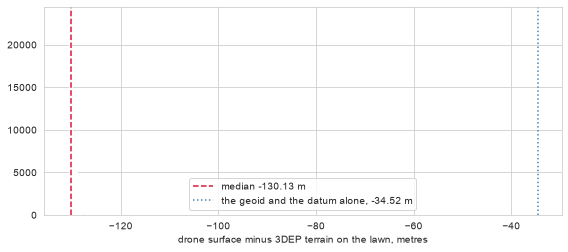

In [4]:
site = gpd.read_file("data/site.gpkg", layer="site").to_crs(dsm.rio.crs)
EDGE_CLEARANCE_M = 8                                       # far enough inside the outline to be clear of the trees at its edge
lawn = site.geometry.iloc[0].buffer(-EDGE_CLEARANCE_M)
lawn_mask = geometry_mask([lawn], out_shape=dsm.shape, transform=dsm.rio.transform(), invert=True)    # True inside the lawn
gap = (dsm - dem).values
d_lawn = gap[lawn_mask & np.isfinite(gap)]
shift = float(np.median(d_lawn))
spread = float(np.median(np.abs(d_lawn - shift)))          # the median distance of a cell from that median, which a few extreme cells cannot drag about
print(f"drone surface minus 3DEP terrain on the lawn: median {shift:+.2f} m over {len(d_lawn):,} cells   reference {h['vertical_shift_m']} m")
print(f"the spread about that median is {spread:.2f} m   reference {h['vertical_shift_mad_m']} m")
print()
n_geoid = reference["terrain"]["geoid18_n_m"]
n_datum = h["datum_height_shift_m"]
print(f"the geoid separation of 03-04 is N = {n_geoid} m, so {n_geoid:+.2f} m of that gap is the difference between sea level and the ellipsoid")
print(f"the datum accounts for a further {n_datum:+.2f} m, since the receiver's ellipsoid is not quite NAD 83's")
print(f"what is left is the receiver's own height error, {shift - n_geoid - n_datum:+.2f} m   reference {h['receiver_height_error_m']} m")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(d_lawn, bins=120, color="0.3")
ax.axvline(shift, color="crimson", linestyle="--", label=f"median {shift:+.2f} m")
ax.axvline(n_geoid + n_datum, color="steelblue", linestyle=":", label=f"the geoid and the datum alone, {n_geoid + n_datum:.2f} m")
ax.set_xlabel("drone surface minus 3DEP terrain on the lawn, metres"); ax.legend()
fig.tight_layout()

Tens of metres of median, and a spread of a few tenths of a metre, which is the important pair. The spread says the two models describe the same lawn to within a few decimetres, which is worse than either instrument claims for itself and is the first hint of the flatness section below; the median says they hang the lawn from different hooks. The three lines under it take that median apart. The geoid accounts for the thirty three metres 03-04 predicted, since the receiver counts from the ellipsoid and the terrain model from sea level. A further metre and a quarter is the datum nobody converted, the one 03-01 measured as zero and the section above declined to apply. What is left is the receiver's own height error, which is the worst of its three coordinates; 03-05 saw a gap of the same size and sign in the aircraft's own absolute altitude, measured at the aircraft rather than on the lawn. Nothing in the software knew any of this. It placed the block where the receiver said, faithfully, and the surface came out tens of metres below the ground it stands on.

So we shift. One number, applied to the drone's two models and stated in the caption of every height that follows. A shift stated is honest; a shift hidden, or a surface quietly snapped onto a terrain so that the two "agree", is a lie about what was measured:

In [5]:
dsm_navd = dsm - shift
dtm_navd = dtm - shift
print(f"the drone's models are now on NAVD88 to within the receiver's error over the block, by a shift of {shift:+.2f} m applied to every cell")
print(f"the field's ground now reads {float(dsm_navd.values[lawn_mask].mean()):.2f} m in the drone's surface against {reference['terrain']['site_ground_m']} m in the 3DEP terrain")

the drone's models are now on NAVD88 to within the receiver's error over the block, by a shift of -130.13 m applied to every cell
the field's ground now reads 42.00 m in the drone's surface against 41.88 m in the 3DEP terrain


Three centimetres between the drone's lawn and the 3DEP terrain's, on the very ground where the shift was measured. That is a check that the arithmetic went the way we intended and nothing more; it says the subtraction is right, not that the block is.

## The height of things

Surface minus terrain is the height of what stands on the ground, and the drone's own pair gives it directly. Here is that difference over the window, and the numbers for the buildings whose footprints the window holds:

31% of the window stands more than 3 m above the terrain   reference 31%
the tallest thing is 25.7 m and the median of what stands above that line is 9.2 m   reference 25.7 m and 9.2 m
             building  above the drone's terrain  above the 3DEP terrain  reference, drone  reference, 3DEP
       Bloomberg Hall                       11.8                    12.5              11.8             12.5
               Hariri                       17.8                    22.5              17.8             22.5
        1912 Pavilion                        4.6                     5.1               4.6              5.1
Carl Icahn Laboratory                        0.0                    14.4               0.0             14.4
69 further buildings were skipped, being too small or lying mostly outside this window


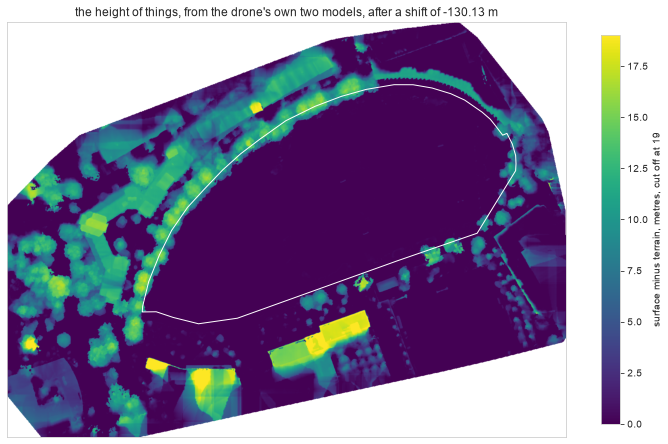

In [6]:
objects = (dsm - dtm).values
extent = (float(dsm.x.min()), float(dsm.x.max()), float(dsm.y.min()), float(dsm.y.max()))
fig, ax = plt.subplots(figsize=(10, 7.5))
top = float(np.nanpercentile(objects, 99.5))               # the colour scale from the data, not from one flight's numbers
im = ax.imshow(objects, extent=extent, cmap="viridis", vmin=0, vmax=top)
site.boundary.plot(ax=ax, color="white", linewidth=1)
fig.colorbar(im, ax=ax, shrink=0.75, label=f"surface minus terrain, metres, cut off at {top:.0f}")
ax.set_title(f"the height of things, from the drone's own two models, after a shift of {shift:+.2f} m", fontsize=12); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

CANOPY_M = 3.0                                             # taller than this and it is a tree, a roof or a wall, not the ground
canopy = objects > CANOPY_M
finite = np.isfinite(objects)
print(f"{np.mean(canopy[finite]):.0%} of the window stands more than {CANOPY_M:.0f} m above the terrain   reference {h['canopy_share_of_window']:.0%}")
print(f"the tallest thing is {np.nanmax(objects):.1f} m and the median of what stands above that line is {np.median(objects[canopy & finite]):.1f} m"
      f"   reference {h['canopy_max_m']} m and {h['canopy_median_m']} m")

above_3dep = (dsm_navd - dem).values                       # computed once, rather than once per building
buildings = gpd.read_file("data/site.gpkg", layer="buildings_site").to_crs(dsm.rio.crs)
rows, skipped = [], 0
for _, b in buildings.iterrows():
    m = geometry_mask([b.geometry], out_shape=objects.shape, transform=dsm.rio.transform(), invert=True) & finite
    cells_expected = b.geometry.area / dsm.rio.resolution()[0] ** 2         # how many cells the footprint should hold
    if m.sum() < 200 or m.sum() < 0.9 * cells_expected:                     # too small, or mostly outside this window
        skipped += 1
        continue
    name = b["name"] if isinstance(b["name"], str) and b["name"] else f"unnamed, {int(b.geometry.area)} square metres"
    rows.append((name, float(np.median(objects[m])), float(np.median(above_3dep[m])),
                 h["buildings"].get(name, {}).get("dsm_minus_dtm_m"), h["buildings"].get(name, {}).get("dsm_minus_3dep_m")))
table = pd.DataFrame(rows, columns=["building", "above the drone's terrain", "above the 3DEP terrain",
                                    "reference, drone", "reference, 3DEP"]).round(1)
print(table.to_string(index=False))
print(f"{skipped} further buildings were skipped, being too small or lying mostly outside this window")

The map is the lecture's normalised height, and it is readable at a glance. The lawn sits at zero, the trees along the paths are blobs of ten metres and more, and the buildings are flat plateaus. The table holds a lesson in its two height columns. A building measured against the drone's own terrain is one height and against the 3DEP terrain another, and the gap between them is not the same for every building: it is largest for the big ones on terraced ground and near zero for a small structure standing on open lawn. That gap is the terrain under the building, which no photograph ever saw and the software filled in from the ground around the footprint, and around a campus building that ground is terraces and plinths. The 3DEP terrain under the same building is an interpolation too, but from measured points under the eaves, and it usually sits lower. Neither is the floor of the building. Both are guesses about ground nobody can see from above, and the height of a building is only as good as the guess beneath it.

## Under the trees

The same question for the trees, where the photographs saw only the crown and the lidar's last returns reached the ground. Where the drone's surface stands more than three metres above its terrain, compare the two terrains:

drone terrain minus 3DEP terrain: under the canopy median +1.44 m, on the lawn -0.02 m   reference 1.44 m and -0.02 m


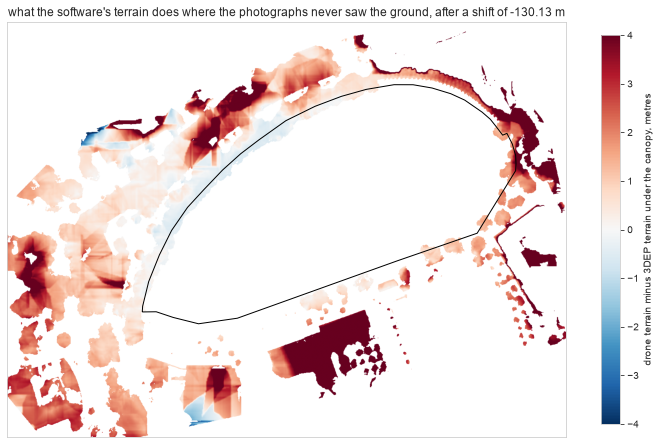

In [7]:
under = (dtm_navd - dem).values
under_trees = under[canopy & np.isfinite(under)]
on_lawn = under[lawn_mask & np.isfinite(under)]
print(f"drone terrain minus 3DEP terrain: under the canopy median {np.median(under_trees):+.2f} m, on the lawn {np.median(on_lawn):+.2f} m   reference {h['dtm_minus_3dep_under_trees_median_m']} m and {h['dtm_minus_3dep_on_lawn_median_m']} m")

fig, ax = plt.subplots(figsize=(10, 7.5))
shown = np.where(canopy, under, np.nan)
im = ax.imshow(shown, extent=extent, cmap="RdBu_r", vmin=-4, vmax=4)
site.boundary.plot(ax=ax, color="black", linewidth=1)
fig.colorbar(im, ax=ax, shrink=0.75, label="drone terrain minus 3DEP terrain under the canopy, metres")
ax.set_title(f"what the software's terrain does where the photographs never saw the ground, after a shift of {shift:+.2f} m", fontsize=12); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

On the lawn the two terrains agree, which they must, since the shift was measured there. Under the trees the software's terrain floats above the 3DEP terrain by a metre and more, and the map shows where: along the tree lines that border the paths, where the software had ground points on one side and the other and drew a straight line between them across the roots, the undergrowth and the slope. The lecture's sentence was that image matching of a town gives a surface, not a terrain, and here is the terrain it gives anyway, an interpolation that is honest on the lawn and a metre optimistic in the shade. Where the ground under trees matters, a stormwater study, a flood line, the lidar is the measurement and the drone is the picture.

## The lawn as a flatness test

The shift above was one number for the whole block. If the block had come out of the adjustment tilted or bent, the lawn's residual against the 3DEP terrain would not be flat, and a playing field is the flattest thing on campus. Fit a plane to the residual over the lawn and see what is left:

the lawn's residual tilts 83 cm per 100 m   reference 83.5
it tilts toward azimuth 91 degrees, clockwise from north
about the median the residual is 65 cm RMS; after the plane is removed 40 cm remains   reference 40.2
95 percent of the lawn's cells lie within 79 cm of the fitted plane   reference 78.5
the two panels share one colour scale, from -1 to +1 m


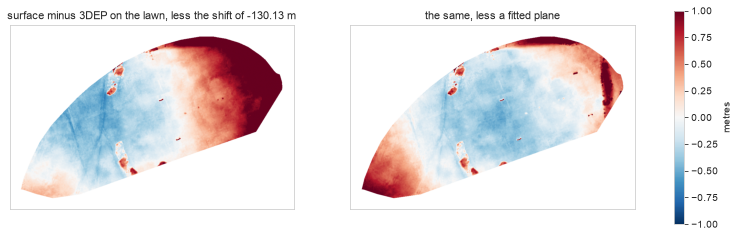

In [8]:
rows_i, cols_i = np.nonzero(lawn_mask & np.isfinite(gap))
xs, ys = dsm.rio.transform() * (cols_i + 0.5, rows_i + 0.5)     # the centre of every lawn cell, in metres
A = np.c_[xs - xs.mean(), ys - ys.mean(), np.ones_like(xs)]     # east, north and a constant: the three unknowns of a plane
coef, *_ = np.linalg.lstsq(A, d_lawn, rcond=None)               # the plane that fits the residual best, by least squares
residual = d_lawn - A @ coef                                    # and what that plane could not explain
tilt_cm_per_100m = np.hypot(coef[0], coef[1]) * 100 * 100      # metres of rise per metre, into centimetres per 100 m
azimuth_deg = np.degrees(np.arctan2(coef[0], coef[1])) % 360
rms_before_cm = np.sqrt(np.mean((d_lawn - shift) ** 2)) * 100   # RMS, the root mean square, i.e. the typical size of a residual counting both signs
rms_after_cm = np.sqrt(np.mean(residual ** 2)) * 100
print(f"the lawn's residual tilts {tilt_cm_per_100m:.0f} cm per 100 m   reference {h['lawn_tilt_cm_per_100m']}")
print(f"it tilts toward azimuth {azimuth_deg:.0f} degrees, clockwise from north")
print(f"about the median the residual is {rms_before_cm:.0f} cm RMS; after the plane is removed {rms_after_cm:.0f} cm remains   reference {h['lawn_residual_rms_cm']}")
print(f"95 percent of the lawn's cells lie within {np.percentile(np.abs(residual), 95) * 100:.0f} cm of the fitted plane   reference {h['lawn_residual_p95_cm']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (title, values) in zip(axes, ((f"surface minus 3DEP on the lawn, less the shift of {shift:+.2f} m", d_lawn - shift), ("the same, less a fitted plane", residual))):
    img = np.full(gap.shape, np.nan)
    img[rows_i, cols_i] = values
    im = ax.imshow(img, extent=extent, cmap="RdBu_r", vmin=-1.0, vmax=1.0)
    ax.set_title(title, fontsize=11); ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(lawn.bounds[0] - 10, lawn.bounds[2] + 10); ax.set_ylim(lawn.bounds[1] - 10, lawn.bounds[3] + 10)
fig.colorbar(im, ax=axes, shrink=0.7, label="metres")
print("the two panels share one colour scale, from -1 to +1 m")

The left panel is the block's shape error laid bare, and the question to ask of it is which of two shapes it is. A lean across the field, high on one side and low on the other, is a tilt, and the fitted plane removes it, so the right panel would come out flat. A pattern whose edges sit on one side of zero and whose middle sits on the other is a bowl or a dome, the plane barely touches it, and the right panel then looks like the left. Whichever this flight shows, the two RMS numbers say how much of it the plane took away, and the one that survives is the block's own bend. Such a bend comes from a self-calibrating adjustment of photographs that all pointed straight down, whose lens model and whose heights trade against each other with nothing on the ground to stop them, and the lecture called it doming. On the pre-flight of 17 September it came out as a bowl of a few decimetres.

There is a second suspect, and honesty requires naming it. The field was rebuilt in 2023, the terrain model's date is not stated and may be older, and a rebuilt field is regraded by decimetres, so part of any pattern here may be the ground itself and not the block. Ground control points measured on the day would have settled which, and pinned the block's corners besides. Without them the block is right to a few decimetres in shape and to metres in height, and 03-08 is about the gap in plan.

## The cloud itself

The two models were made from a point cloud, and the kit carries a thinned sample of it, with each point's colour and the class the software assigned it, ground, low vegetation or building. Here it is along the section line of 03-04, everything within five metres of the line drawn as it was seen:

12,713,513 points in the cloud, 100,000 of them in this sample
  unclassified        2.4%
  ground             69.0%
  low vegetation     19.0%
  building            9.6%
on the lawn the cloud holds about 247 points per square metre   reference 247.2


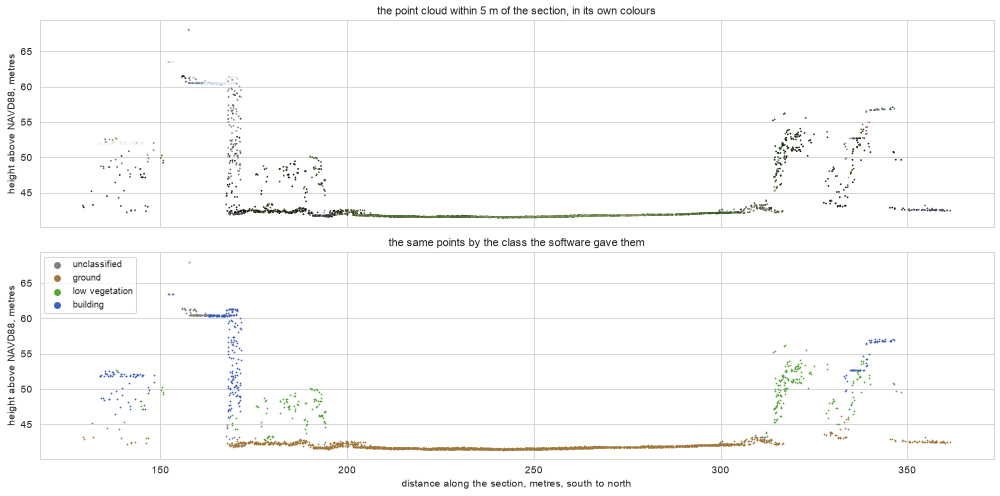

In [9]:
pts = np.load("data/points_sample.npz")
x = pts["dx"].astype("float64") + pts["origin"][0]       # the file stores offsets from an origin, to keep it small
y = pts["dy"].astype("float64") + pts["origin"][1]
z = pts["z"].astype("float64") - shift                   # the same shift as the grids, so the section is on NAVD88 too
classes = json.loads(str(pts["classes"]))
print(f"{int(pts['n_total']):,} points in the cloud, {int(pts['n_sample']):,} of them in this sample")
for code, count in zip(*np.unique(pts["classification"], return_counts=True)):
    print(f"  {classes.get(str(int(code)), f'class {code}'):18} {count / len(pts['classification']):5.1%}")

cloud = gpd.GeoSeries(gpd.points_from_xy(x, y), crs=dsm.rio.crs)      # one layer, so the tests below are vectorised
lawn_pts = cloud.within(lawn).values
print(f"on the lawn the cloud holds about {lawn_pts.sum() * int(pts['n_total']) / int(pts['n_sample']) / lawn.area:.0f} points per square metre   reference {h['points']['density_on_lawn_per_m2']}")

section = gpd.read_file("data/site.gpkg", layer="section").to_crs(dsm.rio.crs).geometry.iloc[0]
SECTION_HALF_WIDTH_M = 5                                  # everything within five metres of the line is drawn
near = (cloud.distance(section) < SECTION_HALF_WIDTH_M).values
along = cloud[near].apply(lambda p: section.project(p)).values
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].scatter(along, z[near], c=pts["rgb"][near] / 255.0, s=3, linewidths=0)
axes[0].set_ylabel("height above NAVD88, metres"); axes[0].set_title("the point cloud within 5 m of the section, in its own colours", fontsize=11)
colours = {2: "#a0783c", 3: "#57a639", 6: "#4060c0", 1: "0.5"}
for c in np.unique(pts["classification"][near]):
    sel = pts["classification"][near] == c
    axes[1].scatter(along[sel], z[near][sel], color=colours.get(int(c), "black"), s=3, linewidths=0, label=classes.get(str(int(c)), str(c)))
axes[1].set_ylabel("height above NAVD88, metres"); axes[1].set_xlabel("distance along the section, metres, south to north"); axes[1].legend(loc="upper left", markerscale=4, fontsize=9)
axes[1].set_title("the same points by the class the software gave them", fontsize=11)
fig.tight_layout()

The upper panel is the section of 03-04 with the buildings and the trees filled in, from the photographs, in colour. The lower is the software's reading of it: brown for the ground it kept for the terrain, green for what it called low vegetation, blue for what it called buildings. Look where the classes go wrong, a tree crown called a building, a bank called vegetation, and look at the density, which is high on the textured ground and thin under the crowns and on the roofs, where the matching had little to hold on to. Every grid of heights above was made from these points, and the points are only as many and as good as the photographs allowed.

## Your turn

Find the tallest thing in the window from the drone's own surface minus terrain, say where it is and what it is, and check whether the 3DEP terrain under it agrees with the software's. The pieces you need all appear above: `objects`, `np.nanargmax`, `np.unravel_index`, and the transform of `dsm` to turn a row and a column into a coordinate.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [10]:
# Your attempt.
#
# row, col = np.unravel_index(np.nanargmax(___), objects.shape)
# px, py = dsm.rio.transform() * (col + 0.5, row + 0.5)
# print(f"the tallest thing stands {objects[row, col]:.1f} m above the drone's terrain at {px:.0f}, {py:.0f}")
# print(f"there the drone's terrain reads {float(dtm_navd.values[row, col]):.1f} m and 3DEP {float(dem.values[row, col]):.1f} m above NAVD88")

## Check your understanding

1. The drone's surface came out tens of metres below the 3DEP terrain. Name the two causes, say which one you could have predicted before the flight and how, and which one you could not.
2. Against the drone's terrain a building measured one height and against the 3DEP terrain another. Which is right, and what would you need to know about the building to say?
3. The lawn's residual was not flat once a single shift had been removed. Say what a set of surveyed ground control points would have done to that pattern, and why no single shift can.
4. The software called some tree crowns buildings. Suggest one rule, using the numbers in this notebook, that would tell the two apart, and one case where it would fail.

## Where we are

You can put three grids of heights from two sources onto one grid, measure where each one's zero is against a reference and take the gap apart into geodesy and instrument error, and subtract only after stating the shift. You can read the height of things off a surface minus a terrain, you know that the terrain under a building or a tree is an interpolation whichever instrument made it, you have tested a block for tilt and bend on the flattest ground available, and you have seen the point cloud that everything above was made from.

The habit worth keeping: before subtracting two height models, put them on one grid, state what each one measures from, measure their gap on ground you trust, and write the shift you applied into the caption.

In 03-08 we ask how right the map is in plan, without a single ground control point to tell us.

## Further resources

Nothing in this course requires anything below.

OpenDroneMap's documentation describes its surface and terrain models and the ground classification behind them: https://docs.opendronemap.org/arguments/dsm/ and https://docs.opendronemap.org/arguments/pc-classify/. The classification is the simple morphological filter of Pingel, Clarke and McBride (2013), ISPRS Journal of Photogrammetry and Remote Sensing 77, pp. 21 to 30.

GEOID18 and the relationship between ellipsoid heights and NAVD88 are explained by the National Geodetic Survey: https://geodesy.noaa.gov/GEOID/GEOID18/. `rioxarray` documents `reproject_match`: https://corteva.github.io/rioxarray/stable/examples/reproject_match.html

The surface model, the terrain model and the point cloud are the course's own flight, published under CC BY 4.0. The 1 m terrain is a public domain work of the US Geological Survey. The outline of Poe Field, the section line and the buildings near it derive from OpenStreetMap, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The tallest thing, from the files themselves so that the cell stands on its own:

```python
import json
import numpy as np
import geopandas as gpd
import rioxarray
from rasterio.enums import Resampling
from rasterio.features import geometry_mask

dsm = rioxarray.open_rasterio("data/dsm_25cm.tif", masked=True).squeeze()
dtm = rioxarray.open_rasterio("data/dtm_50cm.tif", masked=True).squeeze().rio.reproject_match(dsm, resampling=Resampling.bilinear)
dem = rioxarray.open_rasterio("data/dem_3dep_1m_site.tif", masked=True).squeeze().rio.reproject_match(dsm, resampling=Resampling.bilinear)
site = gpd.read_file("data/site.gpkg", layer="site").to_crs(dsm.rio.crs)
lawn_mask = geometry_mask([site.geometry.iloc[0].buffer(-8)], out_shape=dsm.shape, transform=dsm.rio.transform(), invert=True)
gap = (dsm - dem).values
shift = float(np.median(gap[lawn_mask & np.isfinite(gap)]))
objects = (dsm - dtm).values
row, col = np.unravel_index(np.nanargmax(objects), objects.shape)
px, py = dsm.rio.transform() * (col + 0.5, row + 0.5)
print(f"the tallest thing stands {objects[row, col]:.1f} m above the drone's terrain at {px:.0f}, {py:.0f}")
print(f"there the drone's terrain reads {float(dtm.values[row, col]) - shift:.1f} m and 3DEP {float(dem.values[row, col]):.1f} m above NAVD88")
```

Whether the tallest thing is a tree or a building, the map of the height of things tells you at a glance, and so does the point cloud's colour along the section. Whether the terrain under it agrees is the question of the "Under the trees" section: under a crown the software's terrain is likely to sit a metre or more above the lidar's, and under a roof more, so the tallest thing is a little shorter than the drone's own pair says.